# **9장. API 기반 업무 자동화**

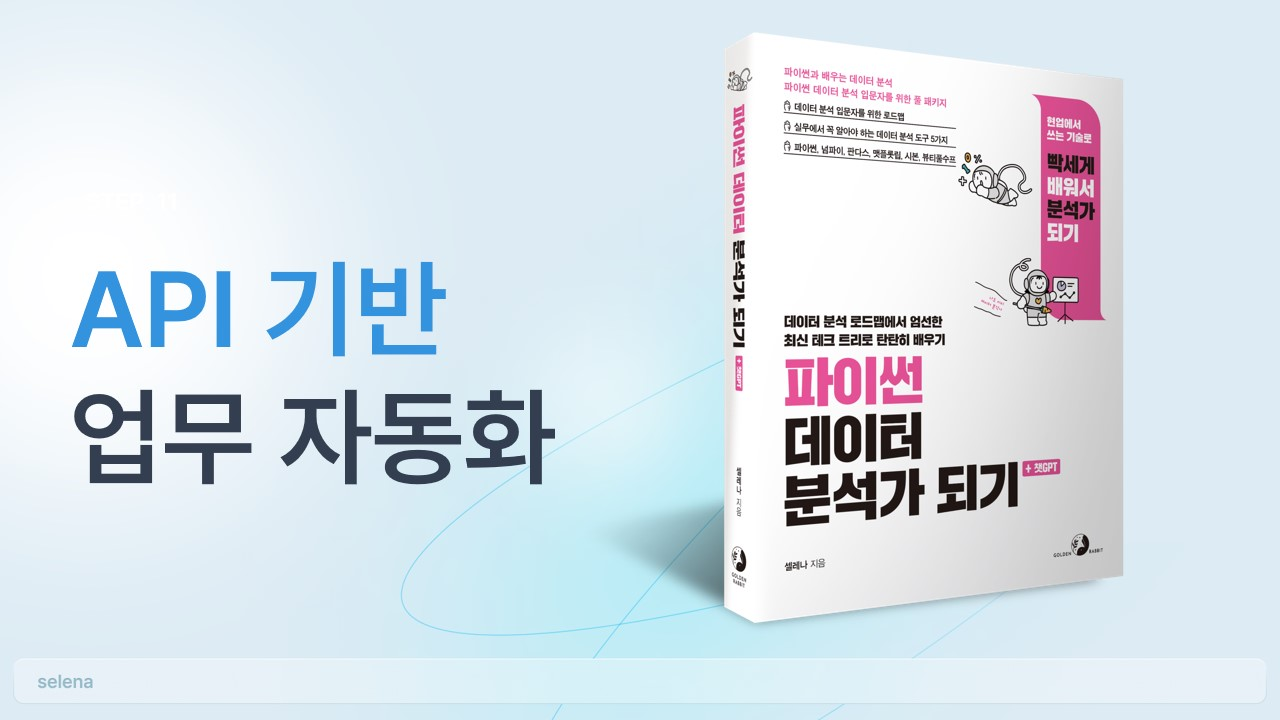

## **09.1 Open API**

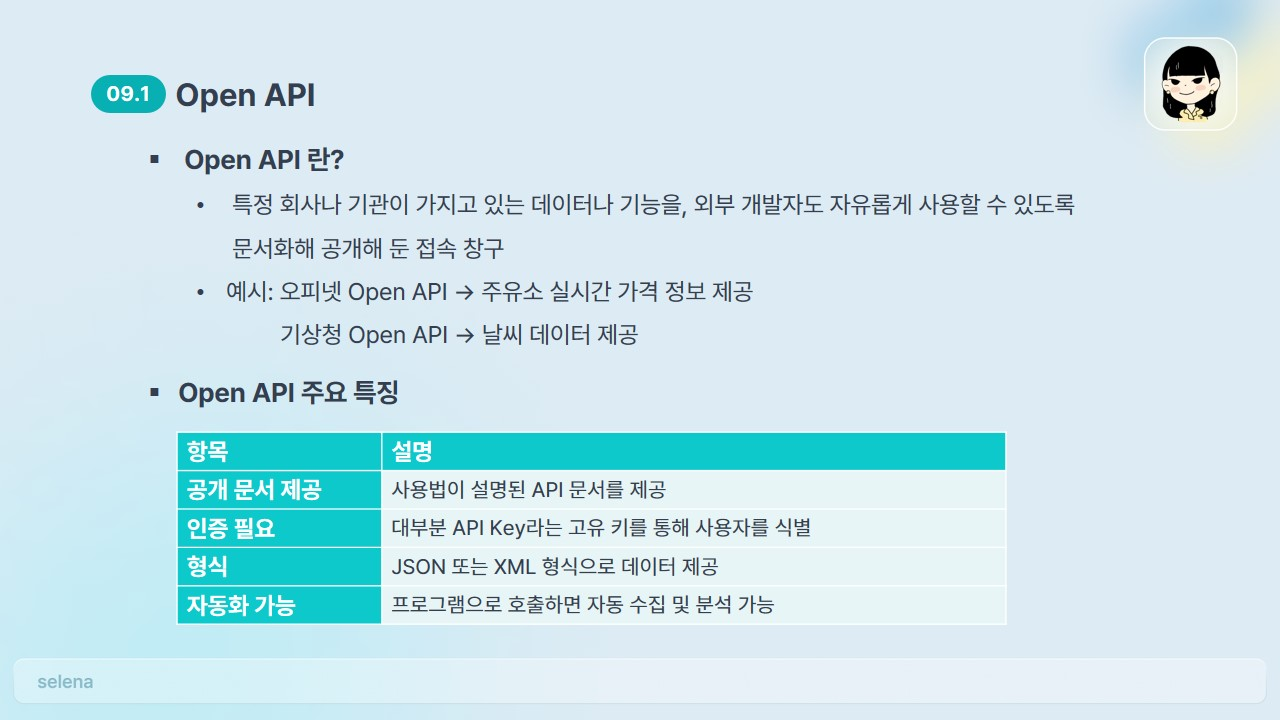

## **09.2 오피넷 Open API 란?**

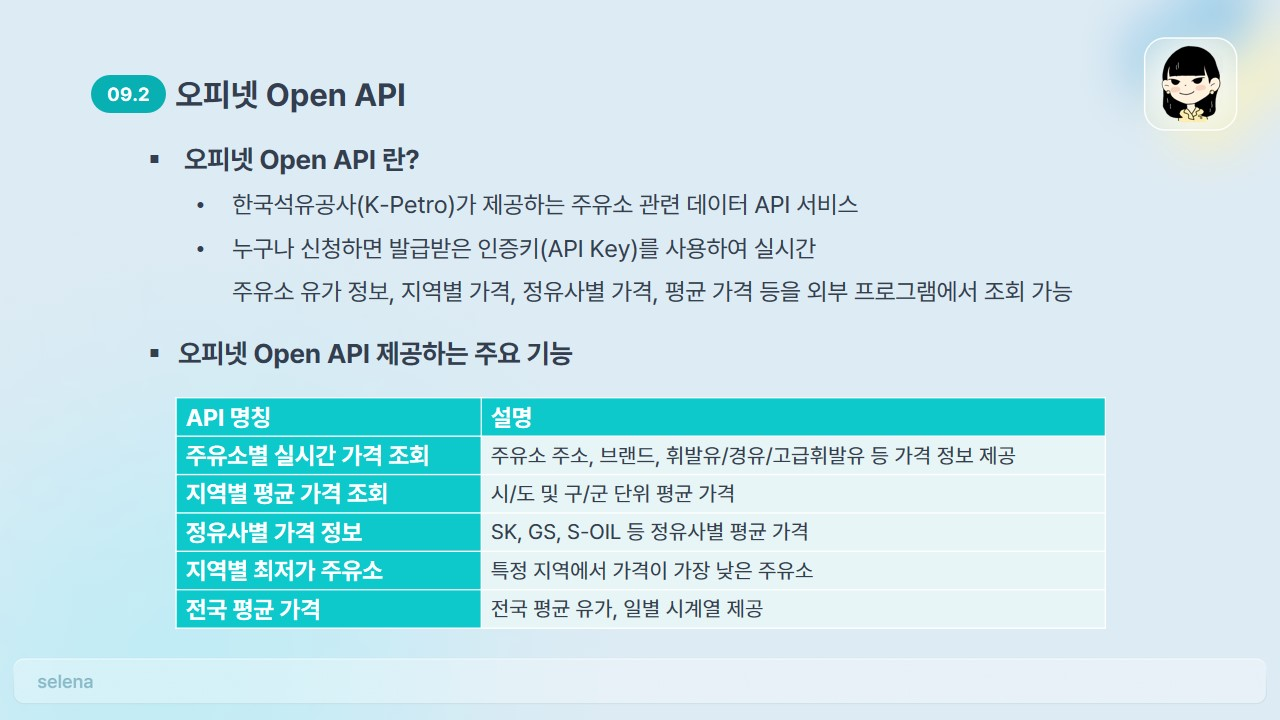


### **오피넷 Open API 데이터 제공 범위**

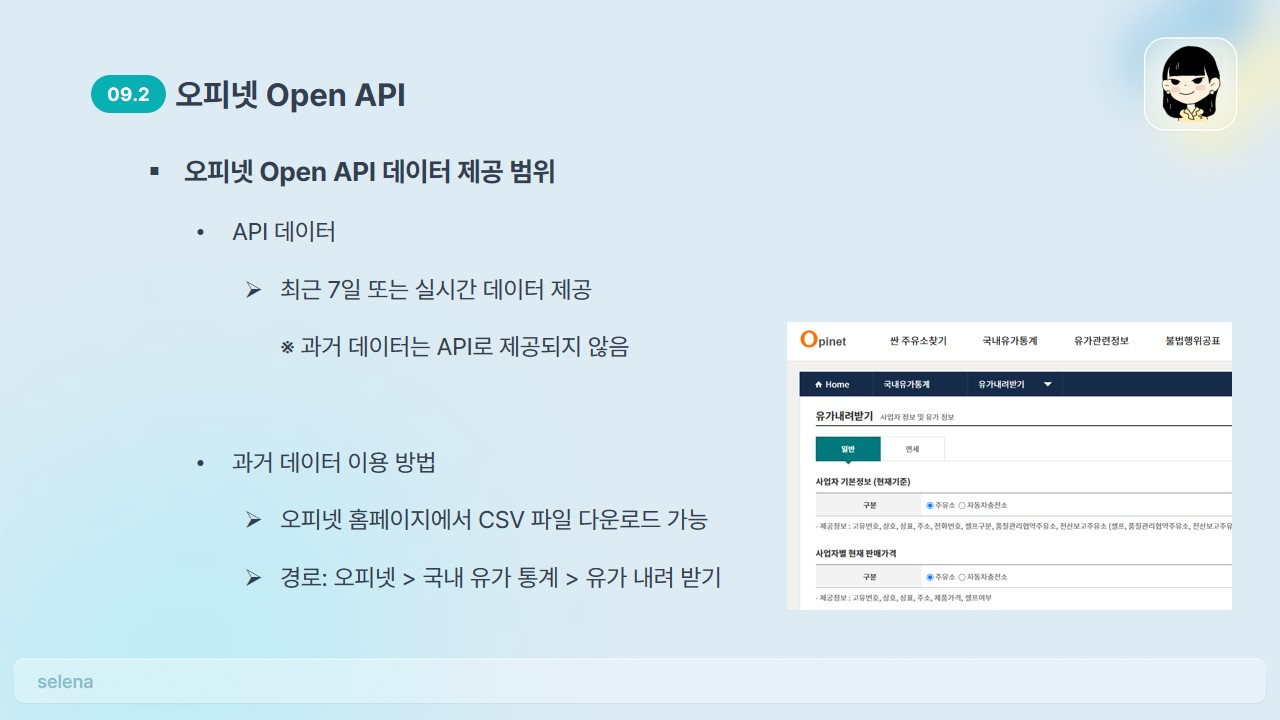

### **오피넷 Open API 활용 방안**

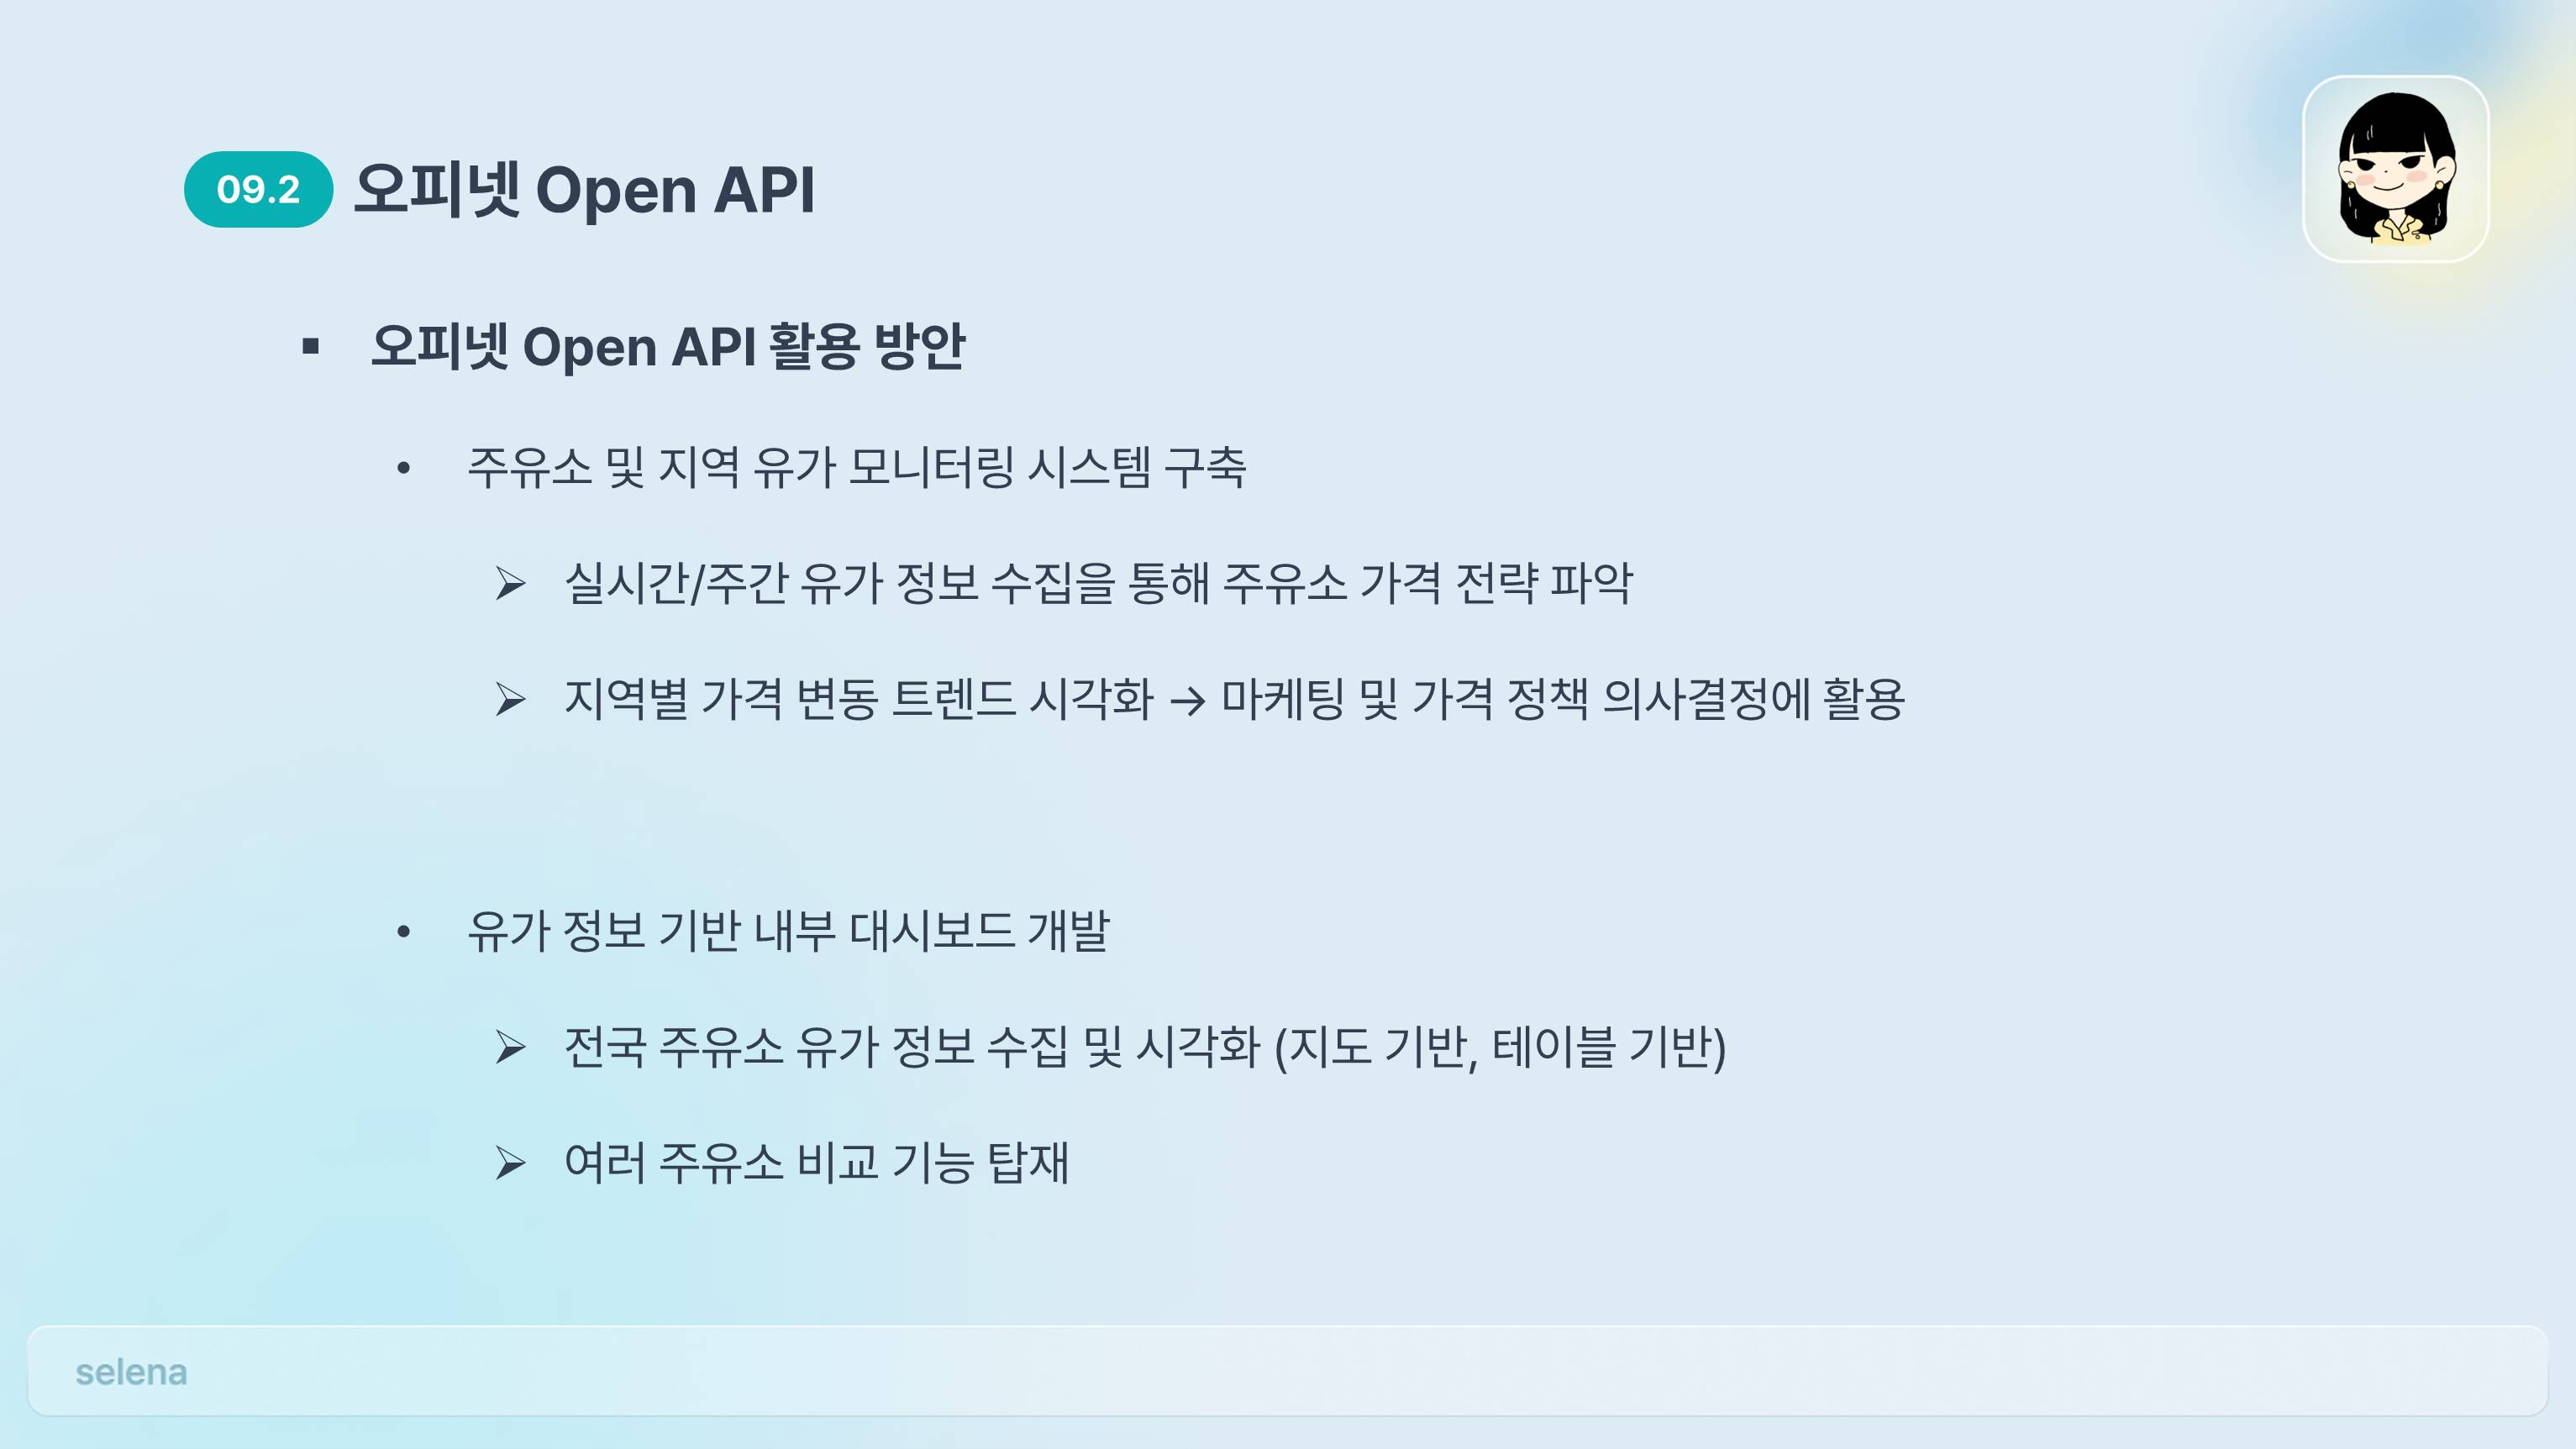

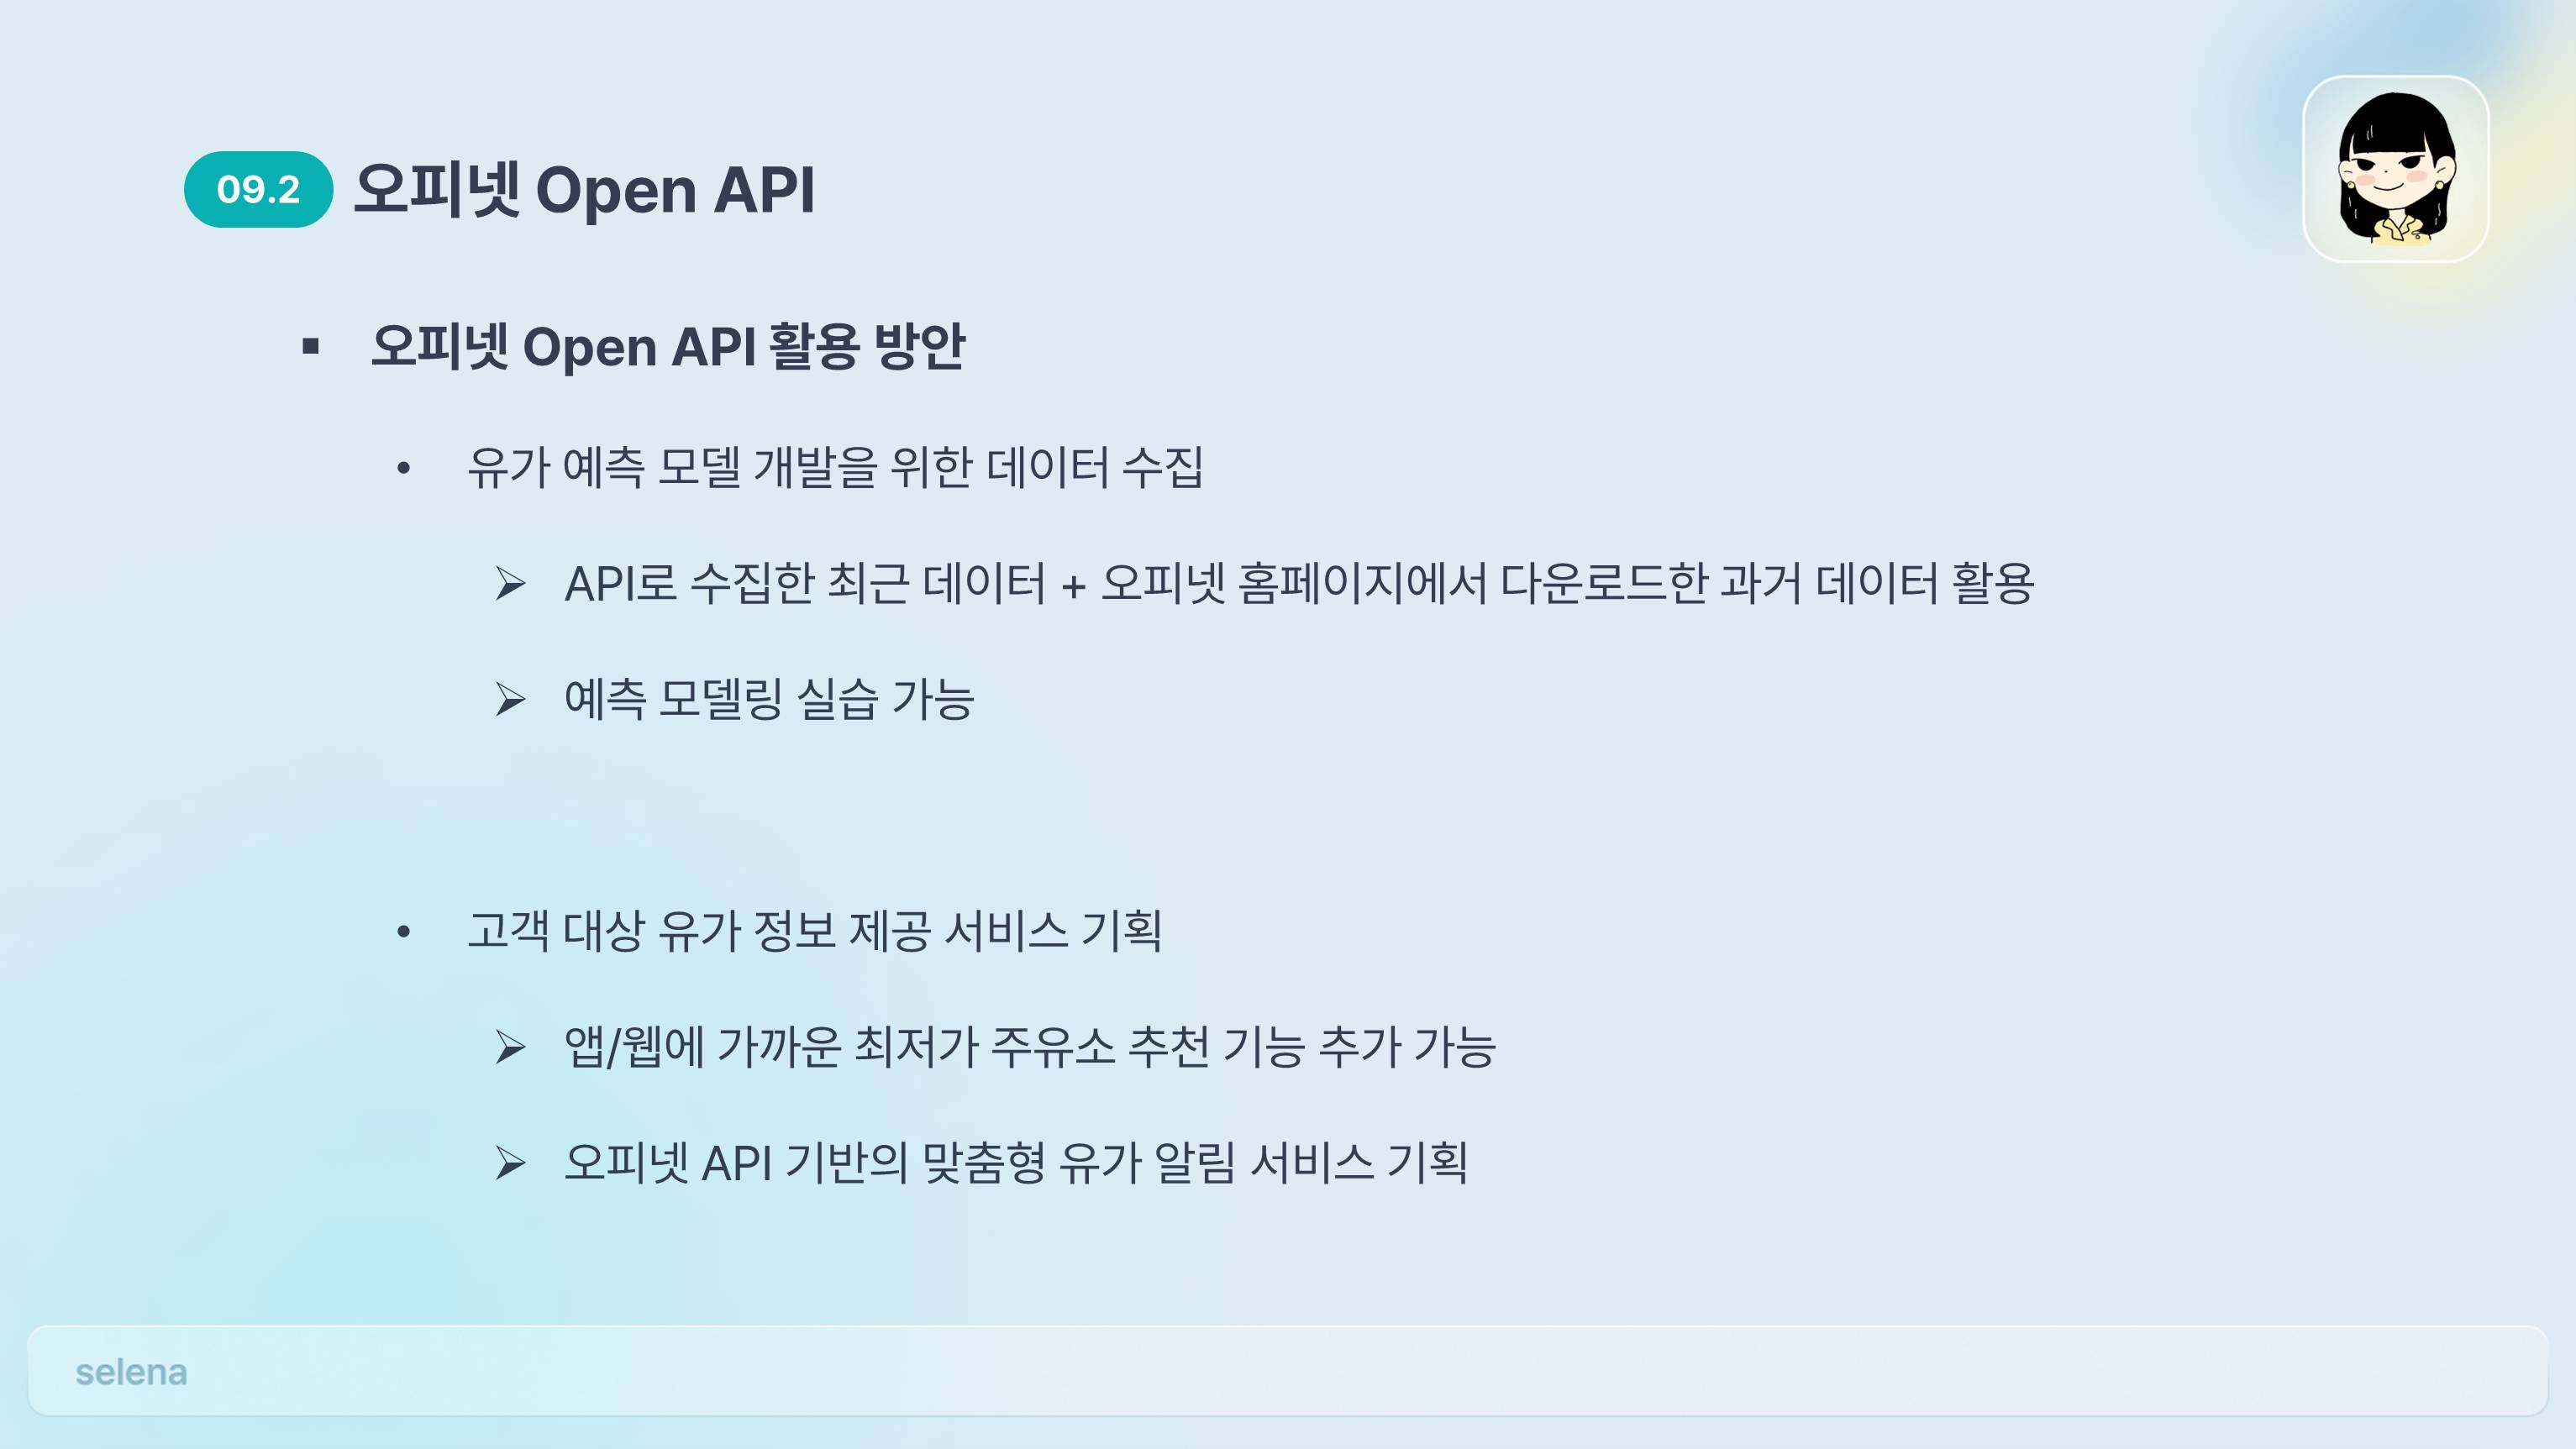

### **한국석유공사 오피넷 무료 API 사용 방법**

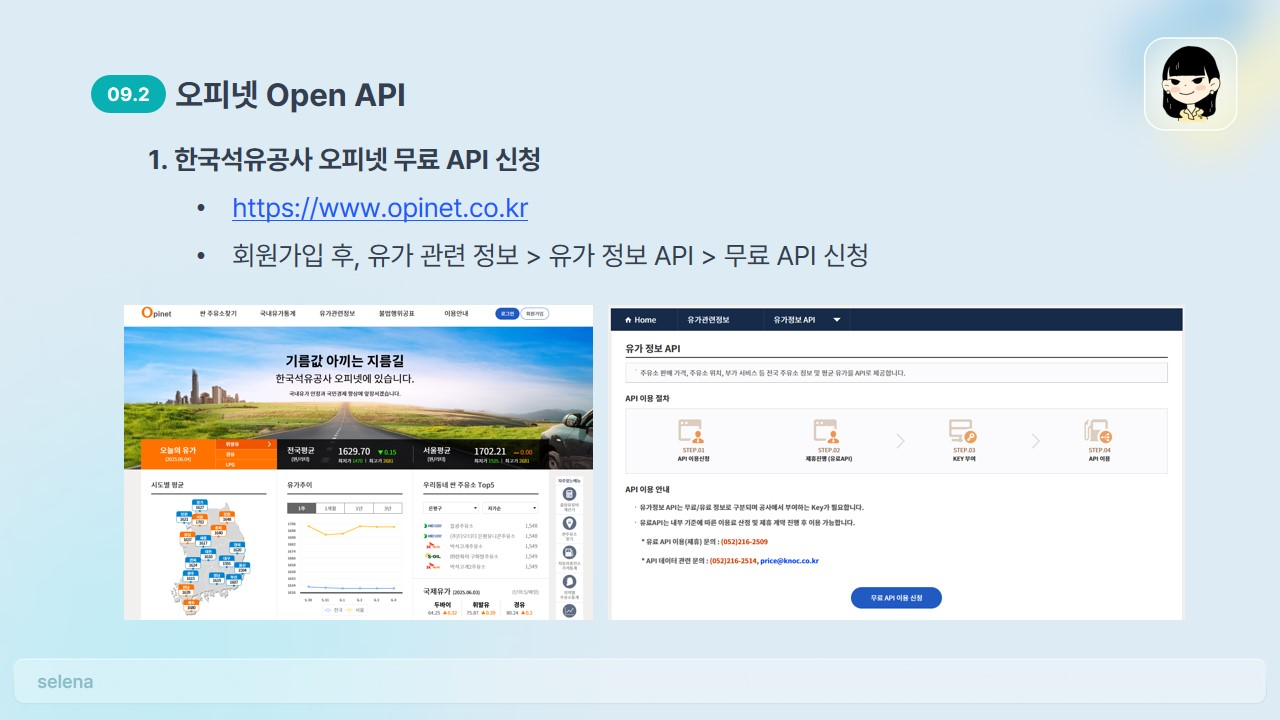

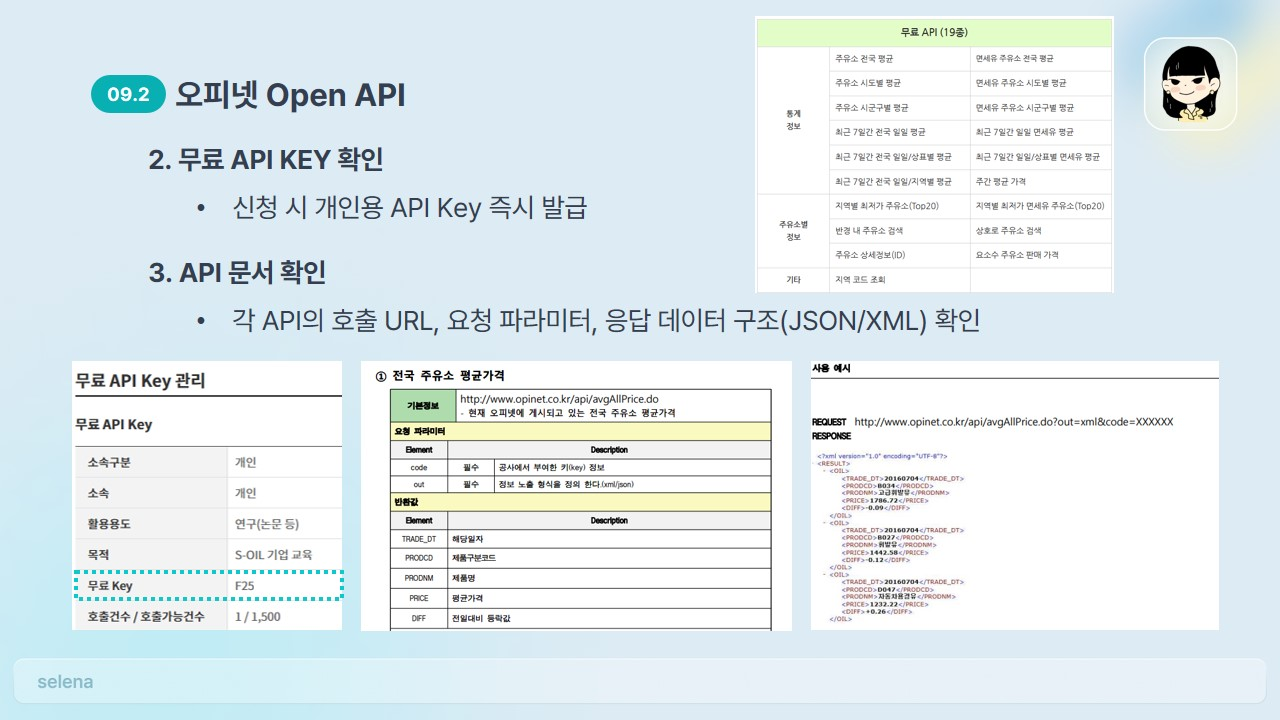

## **09.3 오피넷 Open API 기초 실습**

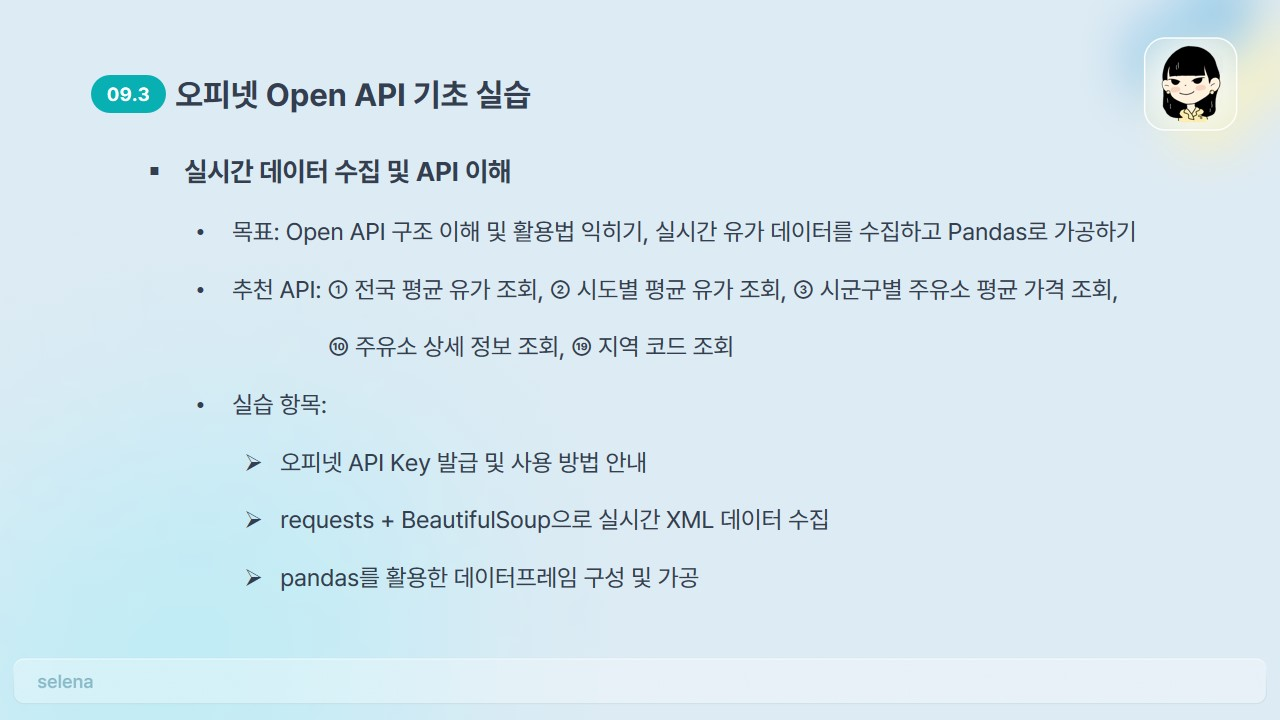

#### **코랩에서 한글 그래프가 깨지는 이유와 해결 방법**

> 구글 코랩(Google Colab) 환경은
기본적으로 한글 폰트가 설치되어 있지 않습니다.

> 그래서 Matplotlib으로 그래프를 그리면 한글이 깨지거나 (□□□) 아예 표시되지 않는 문제가 발생합니다.

#### **해결 방법: koreanize_matplotlib 사용**

> 이 문제는 koreanize_matplotlib 라이브러리를 통해
간단하게 해결할 수 있습니다.

> 해당 라이브러리는 matplotlib의 폰트 설정을 자동으로 변경하여
한글이 정상적으로 출력되도록 만들어줍니다.

#### **중요한 주의사항**

> koreanize_matplotlib를 import한 이후에는
👉 import matplotlib.pyplot as plt를 다시 실행하면 안 됩니다.

> 그 이유는: koreanize_matplotlib가 적용한 한글 폰트 설정이 matplotlib 재import 과정에서 초기화되기 때문입니다.

In [ ]:
!pip install koreanize-matplotlib

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

### **한국석유공사 오피넷 무료 API 사용 방법**

### **API 1번. 전국 평균 유가 조회**

#### API 요청과 응답 처리 과정 이해

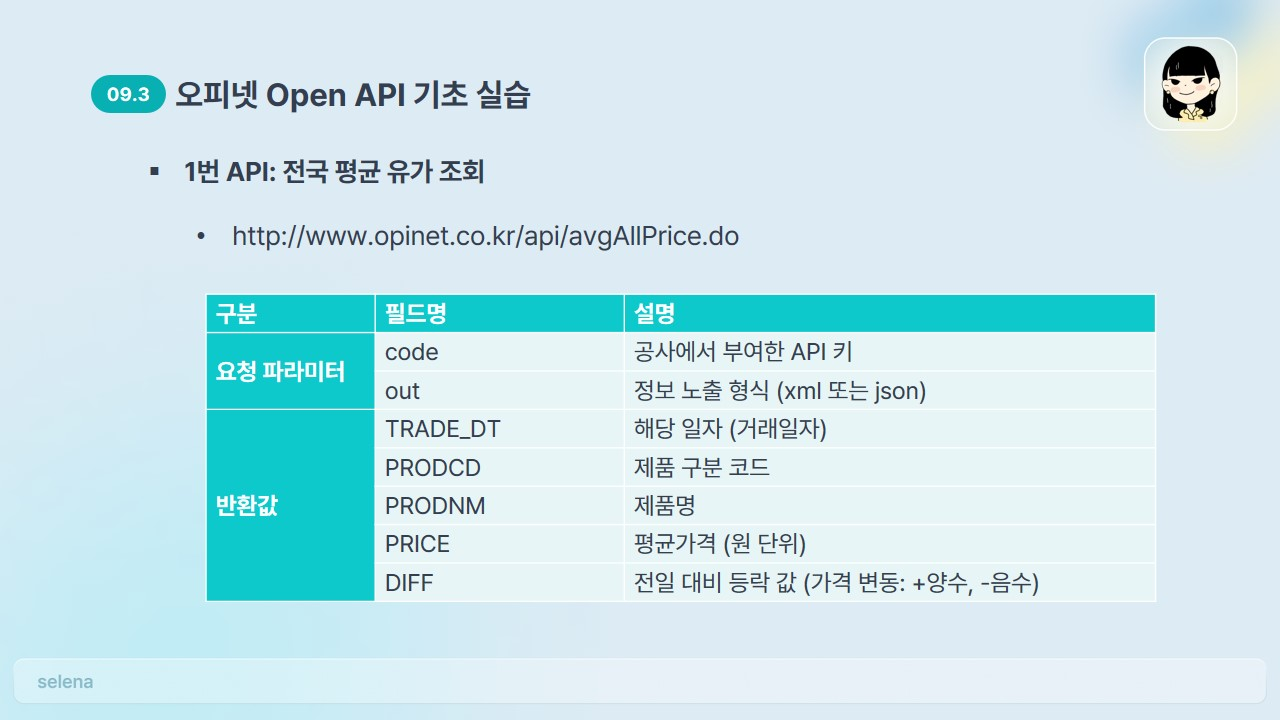

##### 시스템 프롬프트
> 너는 웹 데이터 처리 전문가이자 시니어 파이썬 개발자야. 초급 개발자도 이해할 수 있도록 친절하고 쉽게 설명해줘.

> 내 목표는 requests와 BeautifulSoup를 활용해서 오픈 API에 요청을 보내고, 응답을 받아 필요한 정보를 추출하는 거야.  

> 데이터는 JSON 또는 XML 형식으로 올 수 있으며, 공공데이터 API, 날씨 API, 검색 API 등 다양한 형태가 될 수 있어.  

> 이 템플릿은 다양한 API에 범용적으로 적용될 수 있도록 작성해줘.

> 출력은 마크다운 형식으로 깔끔하게 정리해줘.  

> 코드에 대한 설명은 간결하면서도 초보자도 이해할 수 있게 해줘.  

> 복잡한 개념보다는 실전에서 바로 쓸 수 있는 코드 중심으로 구성해줘.

> 사용하는 라이브러리는 requests와 BeautifulSoup(bs4)만으로 제한해줘.  

> 사용하는 파이썬 버전은 Python 3이며, Python 3 문법으로 작성해줘.  

> 코드는 요청, 응답 확인, 파싱, 출력의 흐름을 따라 주요 단계마다 꼭 주석을 포함해줘.

##### 프롬프트
오피넷의 전국 평균 유가 조회 API(http://www.opinet.co.kr/api/avgAllPrice.do) 를 사용해서, 인증키를 포함한 요청을 보내고, XML 응답에서 각 <OIL> 태그의 제품명(PRODNM)과 평균 가격(PRICE)을 BeautifulSoup으로 파싱하여 '제품명: 가격원' 형식으로 출력하는 파이썬 코드를 만들어줘.

In [ ]:
import requests
from bs4 import BeautifulSoup

# 오피넷 API URL (API 1번. 전국 평균 유가 조회)
url = "   "

# API 요청 시 필요한 파라미터
params = {
    "out": "   ",              # 응답 형식: xml
    "code": "   "              # 개인 인증키 (발급받은 키로 교체)
}

# API 요청 보내기
response =

# XML 데이터를 BeautifulSoup으로 파싱
soup =

print(soup)

In [ ]:
# <OIL> 태그들을 반복하면서 제품명과 가격 추출
for oil in soup.find_all("OIL"):
    prodnm = oil.find("PRODNM").text   # 제품명 (예: 휘발유, 경유 등)
    price = oil.find("PRICE").text     # 평균 가격
    print(f"{prodnm}: {price}원")      # 결과 출력

### **API 2번. 시도별 평균 유가 조회**

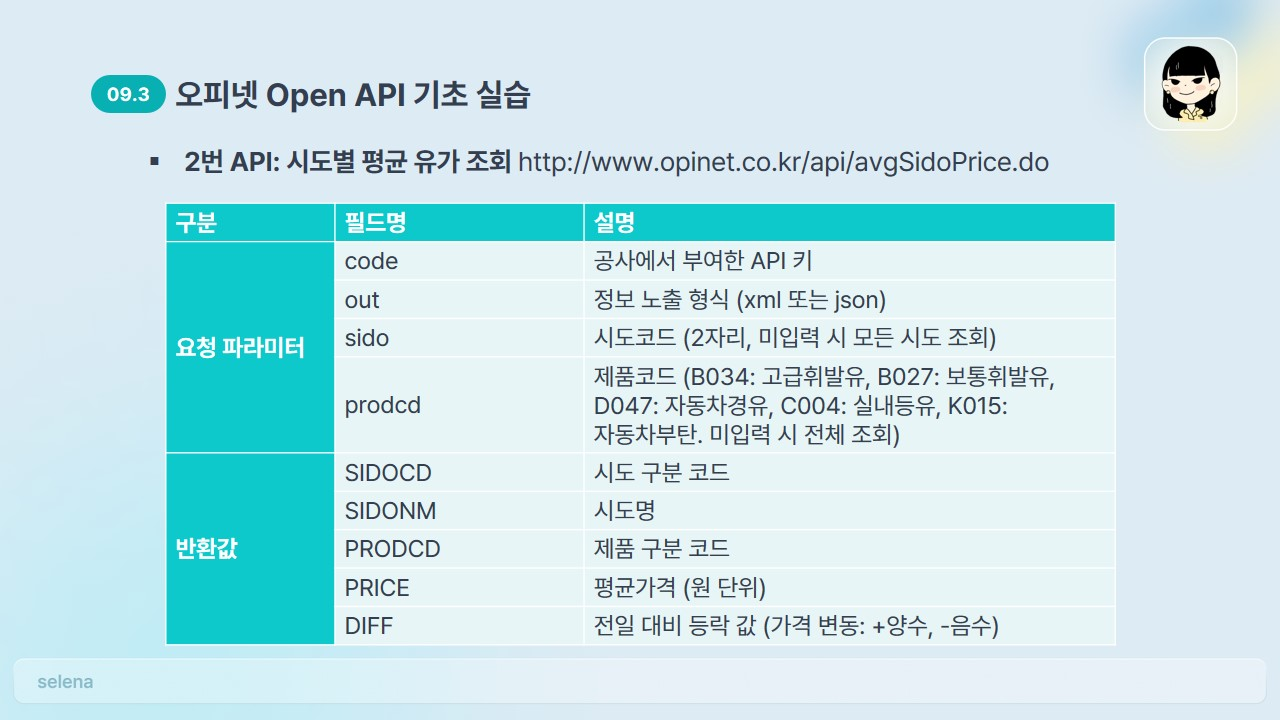

#### XML 데이터 파싱 및 정보 추출 방법 학습


##### 프롬프트

오피넷의 시도별 평균 유가 조회 API(http://www.opinet.co.kr/api/avgSidoPrice.do) 를 사용해서, 인증키를 포함해 XML 형식으로 요청을 보내고, 응답에서 각 <OIL> 태그의 시도명(SIDONM), 제품 코드(PRODCD), 가격(PRICE)을 추출하여 '시도명 - 제품코드: 가격원' 형식으로 출력하는 파이썬 코드를 작성해줘.

In [ ]:
import requests
from bs4 import BeautifulSoup

# 오피넷 API URL (API 2번. 시도별 평균 유가 조회)
url = "   "

# API 요청 시 필요한 파라미터
params = {
    "out": "xml",              # 응답 형식: xml
    "code": "   "       # 개인 인증키 (발급받은 키로 교체)
}

# API 요청 보내기
response = requests.get(url, params=params)

# XML 데이터를 BeautifulSoup으로 파싱
soup = BeautifulSoup(response.content, "xml")

# 'OIL' 태그 반복하며 지역별 유가 정보 출력





#### 판다스를 활용한 데이터 정제 및 전처리 실습

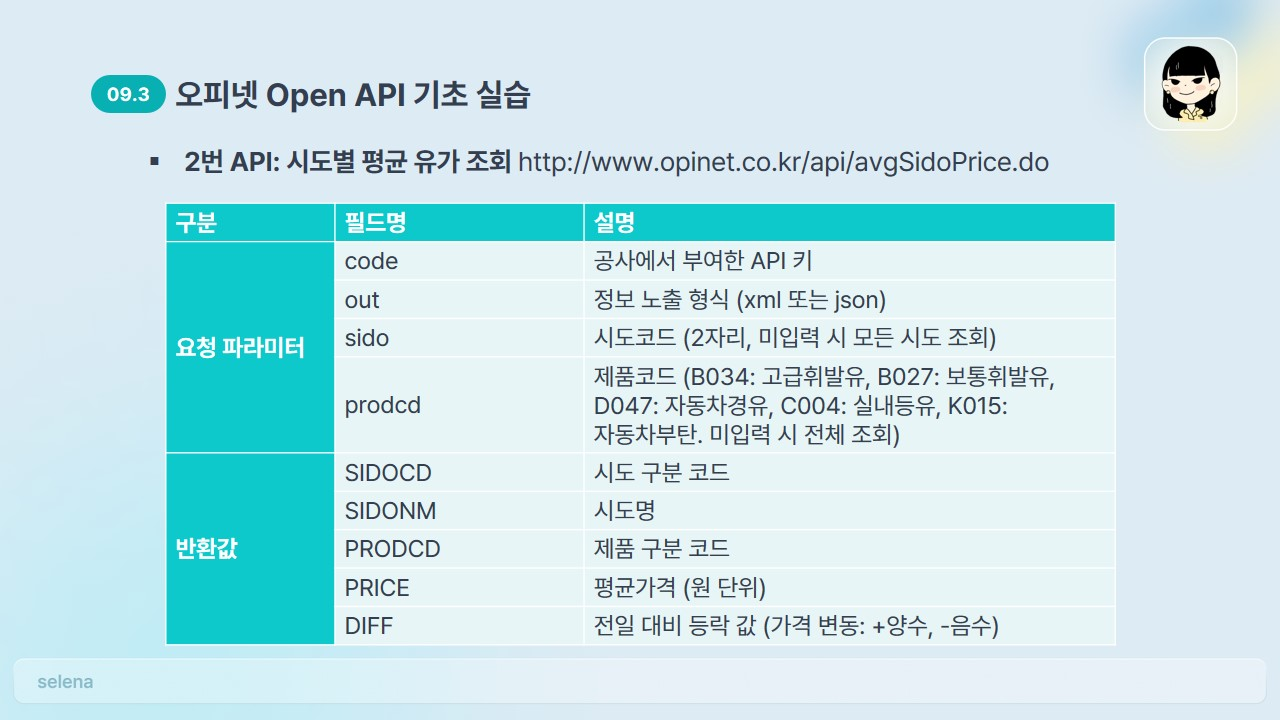

##### 프롬프트
오피넷 시도별 평균 유가 조회 API(avgSidoPrice.do)를 호출해서 XML 응답을 받아, BeautifulSoup으로 시도명(SIDONM), 제품코드(PRODCD), 가격(PRICE) 데이터를 추출한 뒤, 이를 판다스 데이터프레임으로 변환하고, 가격 컬럼을 숫자형으로 변환하는 파이썬 코드를 작성해줘.

In [ ]:
import requests
from bs4 import BeautifulSoup

# 오피넷 API URL (API 2번. 시도별 평균 유가 조회)
url = "   "

# API 요청 시 필요한 파라미터
params = {
    "out": "xml",              # 응답 형식: xml
    "code": "F250604451"       # 개인 인증키 (발급받은 키로 교체)
}

# API 요청 보내기
response = requests.get(url, params=params)

# XML 데이터를 BeautifulSoup으로 파싱
soup = BeautifulSoup(response.content, "xml")


### 프롬프트를 이용하여 코드 생성
# 데이터 리스트 생성

# 데이터프레임 변환

# 가격을 숫자형으로 변환 (선택사항)

# 결과 출력


#### 제품 코드 피처 엔지니어링을 통한 제품명 매핑

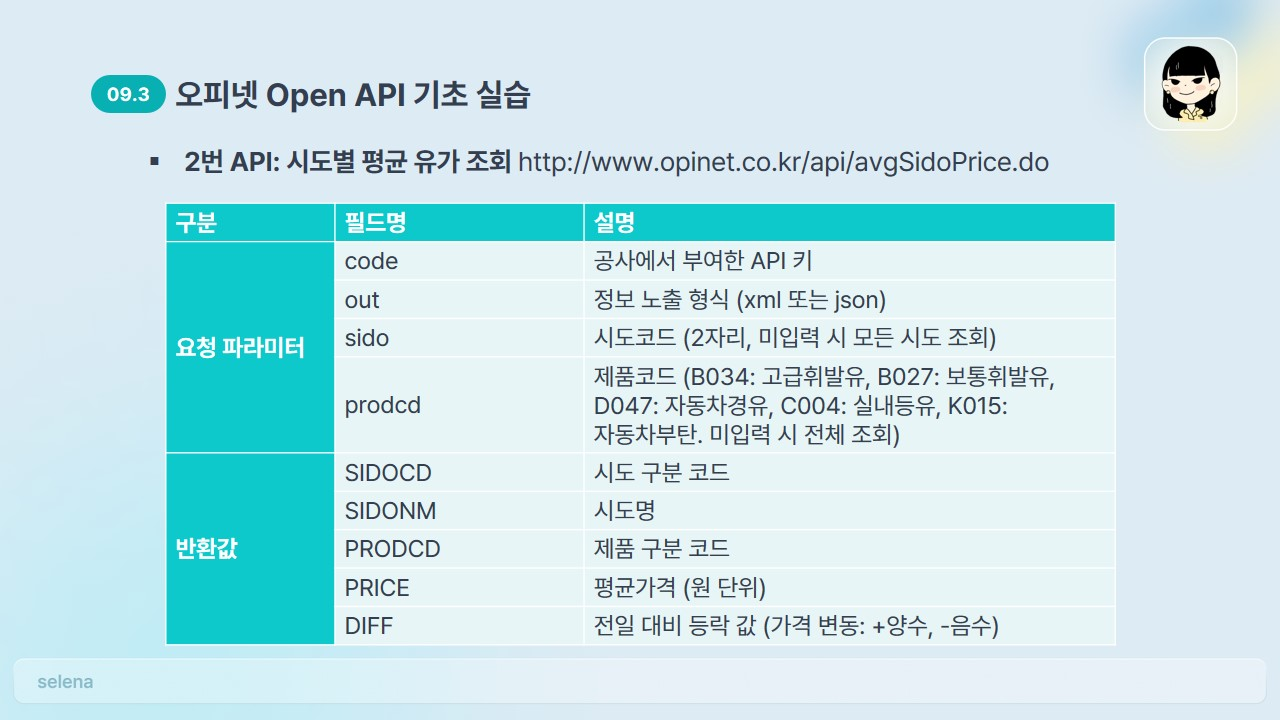

##### 피처엔지니어링
기존 데이터를 활용하여 새로운 변수를 만들어내는 과정

##### 프롬프트
기존 df 데이터프레임에 제품코드(PRODCD)를 제품명으로 바꾸기 위해, 제품코드와 제품명을 매핑하는 딕셔너리를 만들고, map 함수를 사용해 '제품명' 컬럼을 추가하는 파이썬 코드를 작성해줘.

In [ ]:
# 제품코드 → 제품명 매핑 딕셔너리
prod_map = {
    "B034": "고급휘발유",
    "B027": "보통휘발유",
    "D047": "자동차경유",
    "C004": "실내등유",
    "K015": "자동차부탄"
}

# 제품명 컬럼 추가
df["제품명"] =

df

#### 피벗 테이블 사용법 및 데이터 정렬

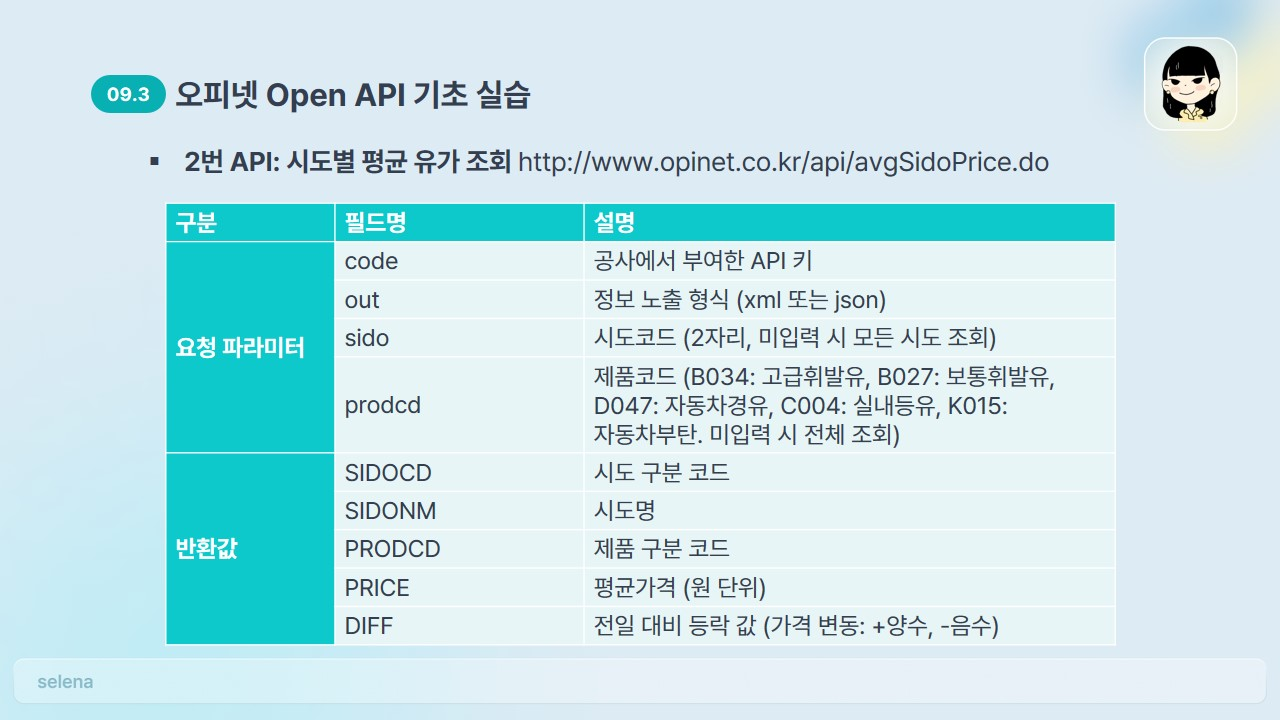

##### 프롬프트
판다스 데이터프레임에서 '지역'을 행 인덱스로, '제품명'을 열로 하여 가격 데이터를 피벗 테이블로 변환하고, 이후 컬럼 순서를 ['지역', '보통휘발유', '고급휘발유', '자동차경유', '실내등유', '자동차부탄'] 순으로 정렬하는 파이썬 코드를 작성해줘.

In [ ]:
# 제품명별 가격을 지역별로 가로 정리
pivot_df = df.pivot_table(
    index="지역",
    columns="제품명",
    values="가격"
).reset_index()

# 보기 좋게 컬럼 순서 정렬 (선택)
column_order = ["지역", "보통휘발유", "고급휘발유", "자동차경유", "실내등유", "자동차부탄"]
pivot_df = pivot_df[column_order]

# 결과 출력
pivot_df

## **09.4 오피넷 Open API 중급 실습**

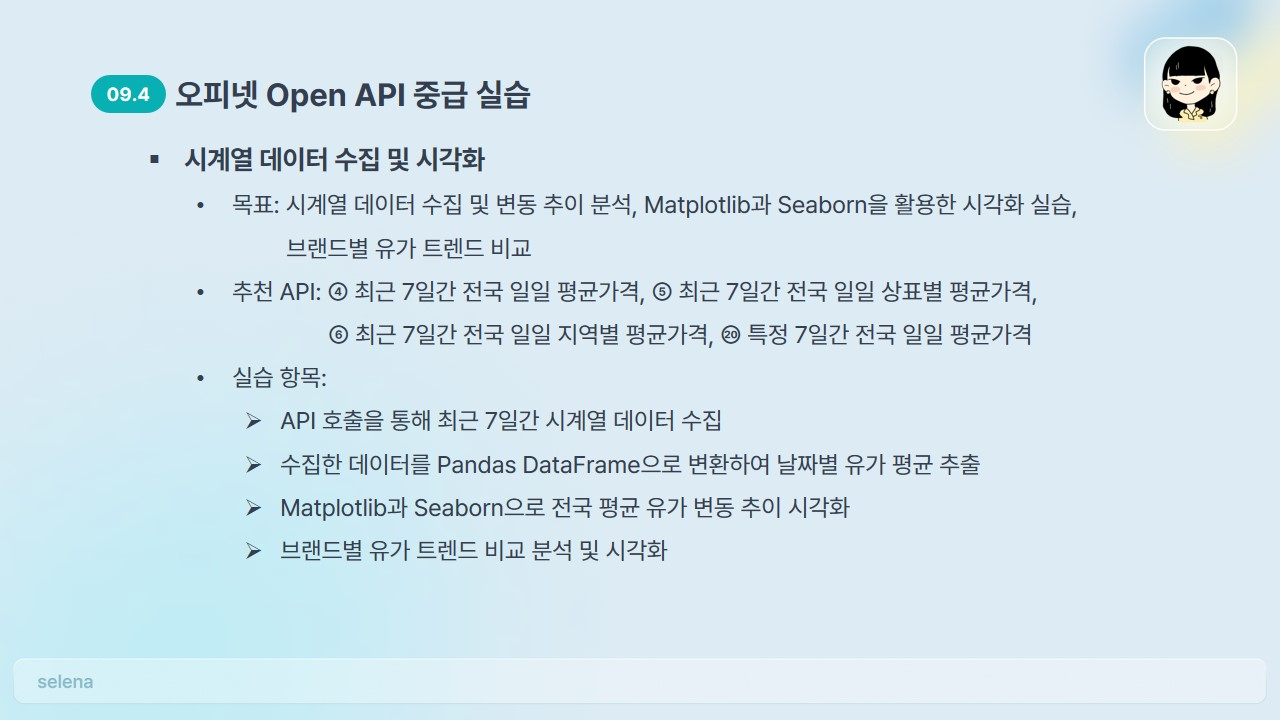

### **API 4번. 최근 7일간 전국 일일 평균 유가 조회**

#### 데이터 파싱 및 정제

![[PPT] S-OIL API 기반 자동화_v3.jpg](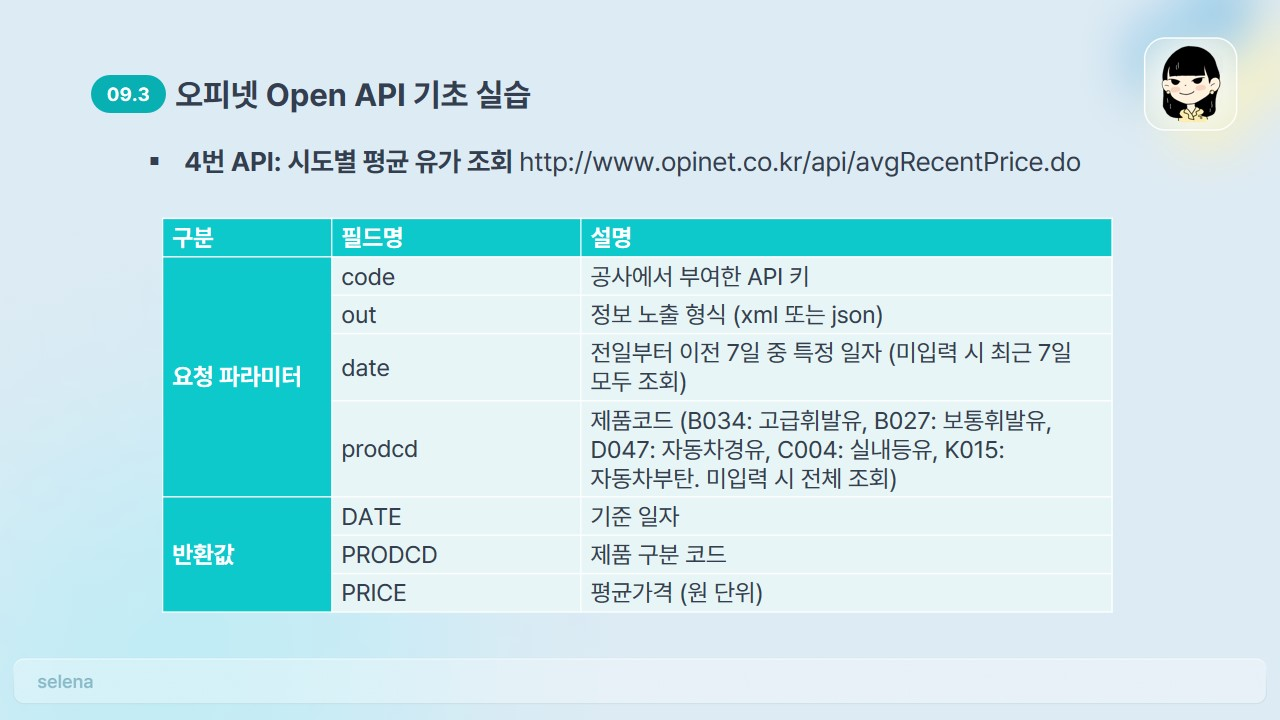)

##### 프롬프트
오피넷의 avgRecentPrice.do API를 사용해서 최근 7일간 전국 평균 유가 정보를 XML 형식으로 받아오고, BeautifulSoup으로 <OIL> 태그에서 날짜(DATE), 제품코드(PRODCD), 가격(PRICE)을 추출한 뒤, 이를 pandas DataFrame으로 변환해줘. 또한 제품코드를 제품명(예: B027 → 보통휘발유)으로 매핑한 컬럼도 추가해줘.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 오피넷 API URL (API 4번. 최근 7일간 전국 일일 평균 유가 조회)
url = "http://www.opinet.co.kr/api/avgRecentPrice.do"

# 요청 파라미터
params = {
    "out": "xml",
    "code": "F250604451"  # 본인의 API 인증키로 교체
}

# API 요청
response = requests.get(url, params=params)

# XML 파싱
soup = BeautifulSoup(response.content, "xml")

# 결과 리스트 초기화
records = []

# 각 <OIL> 태그에서 데이터 추출
for oil in soup.find_all("OIL"):
    date = oil.find("DATE").text           # 날짜 (yyyy-mm-dd)
    product_code = oil.find("PRODCD").text # 제품 코드 (예: B027)
    price = oil.find("PRICE").text         # 가격

    records.append({
        "date": date,
        "product_code": product_code,
        "price": float(price)
    })

# DataFrame 생성
df = pd.DataFrame(records)

# 제품코드 → 제품명 매핑 (선택)
product_map = {
    "B027": "Regular Gasoline",
    "B034": "Premium Gasoline",
    "D047": "Diesel",
    "C004": "Kerosene",
    "K015": "LPG"
}

df["product_name"] = df["product_code"].map(product_map)

# 결과 출력
df

#### 시계열 데이터 재구성 및 피벗 테이블

![[PPT] S-OIL API 기반 자동화_v3.jpg](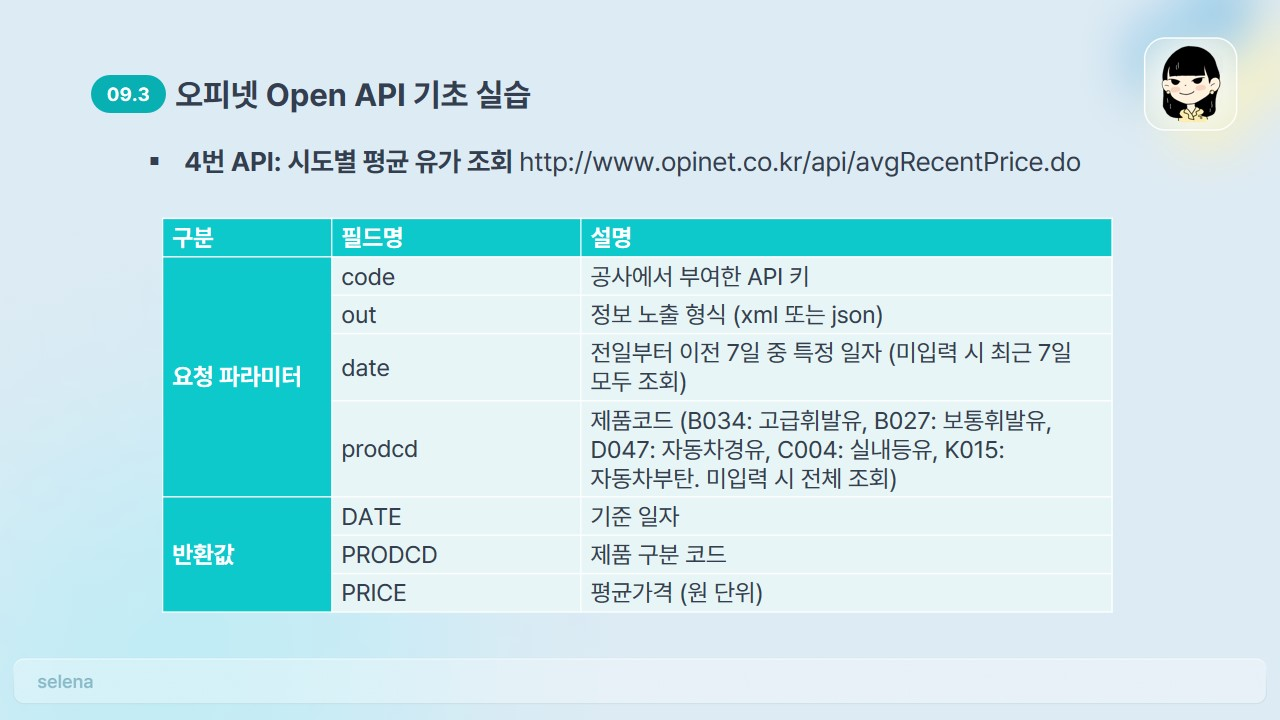)

##### 프롬프트
최근 7일간의 전국 평균 유가 데이터를 활용해, 날짜를 행으로, 제품명을 열로 하여 가격을 값으로 정리한 피벗 테이블을 생성하고 싶습니다. 제품명은 영어로 바꾸고, 인덱스는 날짜(Date)로 설정해주세요.


In [ ]:
# 피벗 테이블 생성: 날짜를 행, 제품명을 열로 정리
pivot_df = df.pivot_table(index="date", columns="product_name", values="price")
pivot_df.columns = ["Regular Gasoline", "Premium Gasoline", "Kerosene", "Diesel", "Butane Gas"]

# 인덱스 이름 지정
pivot_df.index.name = "Date"

pivot_df

#### 연료별 일일 가격 변동률 시각화
> 가격 변화가 미미한 절대 가격과 달리, 변동률 시각화는 일별 상승 및 하락 추이를 명확히 보여줌

> 제품별 변동성을 비교하기 좋고, 시장의 단기 동향 파악에 유용

##### 프롬프트
> import matplotlib.pyplot as plt 코드는 제외해줘.

> matplotlib과 seaborn으로 pivot_df의 일별 제품별 가격 변화율(%)을 계산해, 5개 제품을 5행 1열 서브플롯으로 그려줘. 각 그래프는 점 표시, 제목과 y축 라벨, 범례가 포함되고, x축은 공유하며 45도 회전한 날짜를 표시해줘. 스타일은 whitegrid, 크기는 (12,18)로 설정해줘

#### 연료별 가격 상관관계 히트맵

> 각 연료 가격 간 상관관계를 파악해 시장 내 연료별 가격 움직임의 동조성 여부 분석

> 부드러운 색상 조합으로 정보를 쉽게 전달하고, 중요한 패턴을 눈에 띄게 강조

##### 프롬프트
> import matplotlib.pyplot as plt 코드는 제외해줘.

> pivot_df의 상관관계를 seaborn 히트맵으로 그려줘. 크기는 8x6, 연한 파스텔톤 diverging 컬러맵을 사용하고, 상관계수 숫자 표시, 축 눈금 45도 회전, 제목 ‘Correlation Between Fuel Prices (Soft Colors)’ 포함해줘